In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv("irrigation_prediction.csv")

In [5]:
df.head()

,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,Clay,6.14,36.48,0.42,2.17,21.90,31.19,1167.70,4.01,1.97,Wheat,Vegetative,Rabi,Rainfed,Reservoir,4.73,Yes,1.98,South,Low
1,Silt,6.41,50.56,0.38,0.23,36.50,26.01,831.28,10.72,16.82,Maize,Flowering,Zaid,Canal,Groundwater,12.22,Yes,33.56,Central,Medium
2,Sandy,7.71,40.07,1.09,2.18,41.83,76.41,1844.45,7.75,19.03,Cotton,Harvest,Rabi,Drip,Reservoir,5.52,Yes,34.62,South,Low
3,Clay,5.96,12.75,1.56,0.40,37.22,43.32,306.26,8.90,11.44,Wheat,Sowing,Kharif,Canal,Reservoir,1.43,Yes,84.03,North,Medium
4,Clay,7.76,18.58,0.95,2.52,22.38,86.44,1875.63,10.39,11.26,Cotton,Sowing,Zaid,Canal,River,2.52,No,60.86,South,Medium


In [47]:
Duplicated = df.duplicated()

print(f"Nombre de doublons :  {Duplicated.sum()}")

Nombre de doublons :  0


In [6]:
df.dtypes

Soil_Type                   object
Soil_pH                    float64
Soil_Moisture              float64
Organic_Carbon             float64
Electrical_Conductivity    float64
Temperature_C              float64
Humidity                   float64
Rainfall_mm                float64
Sunlight_Hours             float64
Wind_Speed_kmh             float64
Crop_Type                   object
Crop_Growth_Stage           object
Season                      object
Irrigation_Type             object
Water_Source                object
Field_Area_hectare         float64
Mulching_Used               object
Previous_Irrigation_mm     float64
Region                      object
Irrigation_Need             object
dtype: object

In [7]:
df.isnull().sum()

Soil_Type                  0
Soil_pH                    0
Soil_Moisture              0
Organic_Carbon             0
Electrical_Conductivity    0
Temperature_C              0
Humidity                   0
Rainfall_mm                0
Sunlight_Hours             0
Wind_Speed_kmh             0
Crop_Type                  0
Crop_Growth_Stage          0
Season                     0
Irrigation_Type            0
Water_Source               0
Field_Area_hectare         0
Mulching_Used              0
Previous_Irrigation_mm     0
Region                     0
Irrigation_Need            0
dtype: int64

In [8]:
df.describe()

,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,Previous_Irrigation_mm
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,6.487857,36.969207,0.944731,1.791963,26.991423,60.080339,1252.499420,7.518538,10.163545,7.598024,59.864122
std,0.979963,16.430845,0.372406,0.984202,8.664074,20.187973,715.582201,2.016077,5.670923,4.233919,34.483722
min,4.800000,8.000000,0.300000,0.100000,12.000000,25.000000,0.380000,4.000000,0.500000,0.300000,0.020000
25%,5.640000,22.860000,0.620000,0.940000,19.460000,42.855000,634.155000,5.760000,5.160000,3.950000,30.160000
50%,6.470000,37.240000,0.950000,1.780000,27.090000,60.040000,1250.335000,7.560000,10.190000,7.540000,59.630000
75%,7.350000,50.940000,1.260000,2.650000,34.500000,77.705000,1880.265000,9.260000,15.100000,11.202500,90.030000
max,8.200000,65.000000,1.600000,3.500000,42.000000,95.000000,2499.690000,11.000000,20.000000,15.000000,119.990000


In [9]:
var_cat = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
var_cat

['Soil_Type',
 'Crop_Type',
 'Crop_Growth_Stage',
 'Season',
 'Irrigation_Type',
 'Water_Source',
 'Mulching_Used',
 'Region',
 'Irrigation_Need']

In [10]:
for column in var_cat:
    print(f"Les valeurs uniques de {column}")
    print(df[column].unique())
    
    print("=========================================================")

Les valeurs uniques de Soil_Type
['Clay' 'Silt' 'Sandy' 'Loamy']
Les valeurs uniques de Crop_Type
['Wheat' 'Maize' 'Cotton' 'Rice' 'Sugarcane' 'Potato']
Les valeurs uniques de Crop_Growth_Stage
['Vegetative' 'Flowering' 'Harvest' 'Sowing']
Les valeurs uniques de Season
['Rabi' 'Zaid' 'Kharif']
Les valeurs uniques de Irrigation_Type
['Rainfed' 'Canal' 'Drip' 'Sprinkler']
Les valeurs uniques de Water_Source
['Reservoir' 'Groundwater' 'River' 'Rainwater']
Les valeurs uniques de Mulching_Used
['Yes' 'No']
Les valeurs uniques de Region
['South' 'Central' 'North' 'East' 'West']
Les valeurs uniques de Irrigation_Need
['Low' 'Medium' 'High']


In [11]:
var_cat

['Soil_Type',
 'Crop_Type',
 'Crop_Growth_Stage',
 'Season',
 'Irrigation_Type',
 'Water_Source',
 'Mulching_Used',
 'Region',
 'Irrigation_Need']

Analyse univariée des variables catégorielles

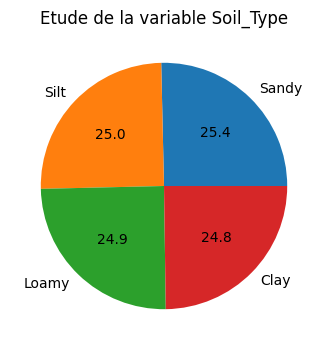

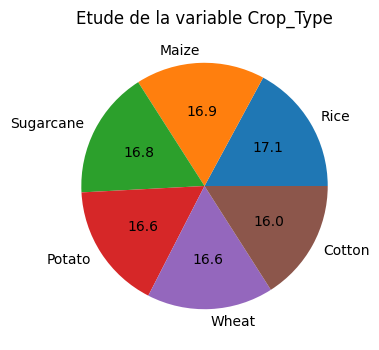

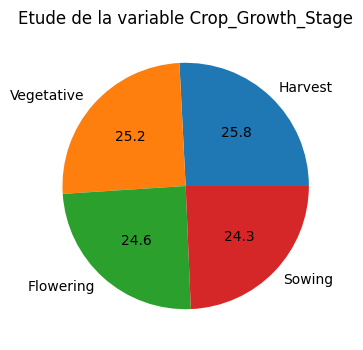

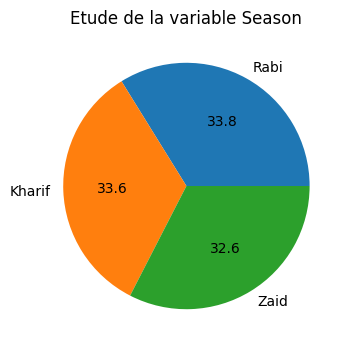

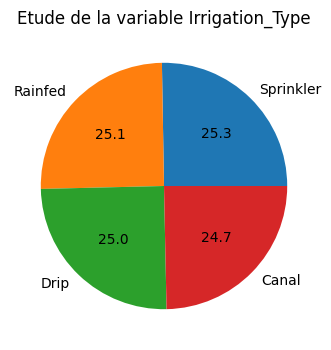

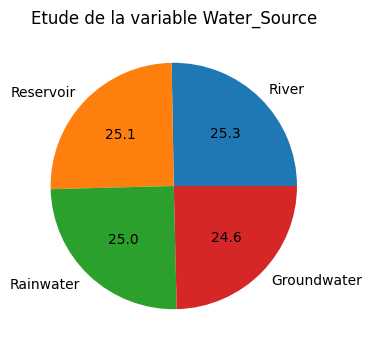

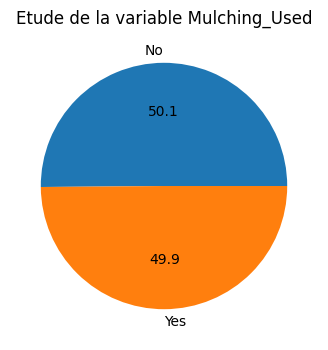

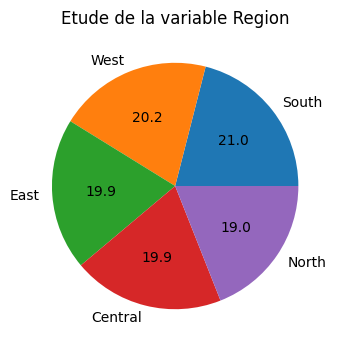

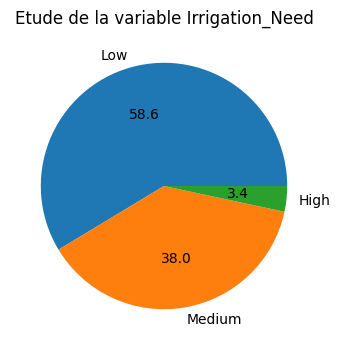

In [ ]:
#Etude des variables qualitatives 

for col in var_cat:
    plt.figure(figsize=(4, 4))
    df[col].value_counts().plot.pie(autopct='%1.1f')
    plt.ylabel('')
    plt.title(f'Etude de la variable {col}')
    plt.show()

La variable cible présente un déséquilibre important : Low (58,6 %), Medium (38 %) et High (3,4 %).

La classe High étant très sous-représentée, le modèle à utiliser risque de se concentrer sur les classes majoritaires et d’ignorer cette modalité.

Ainsi, une bonne accuracy peut être obtenue tout en ayant de mauvaises performances sur la classe High, ce qui peut introduire un biais dans les prédictions.

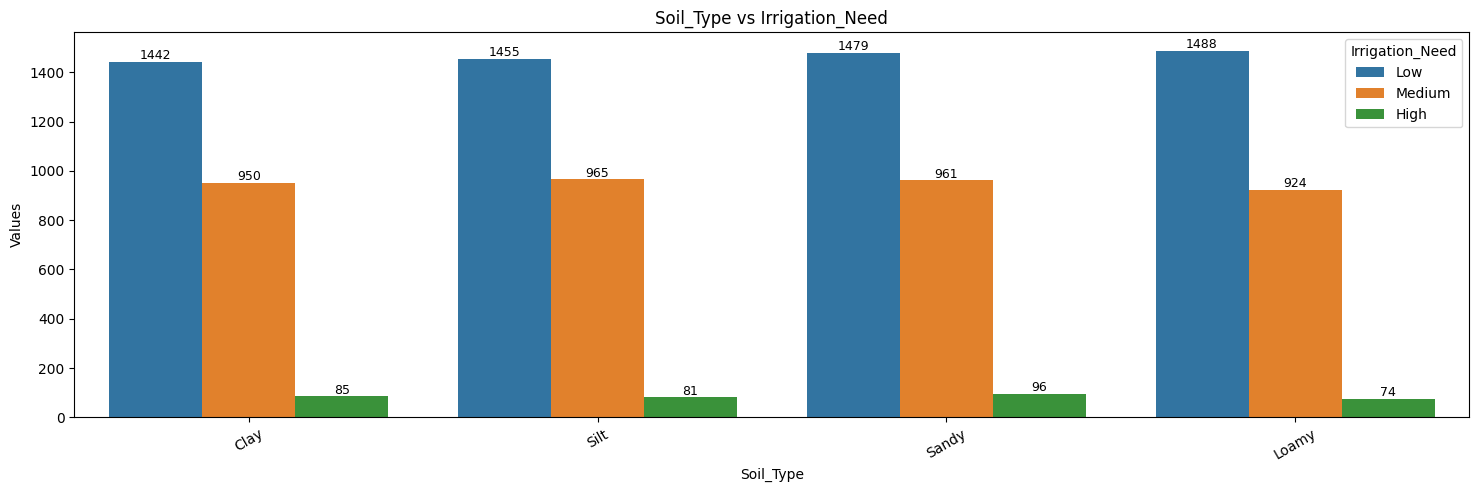

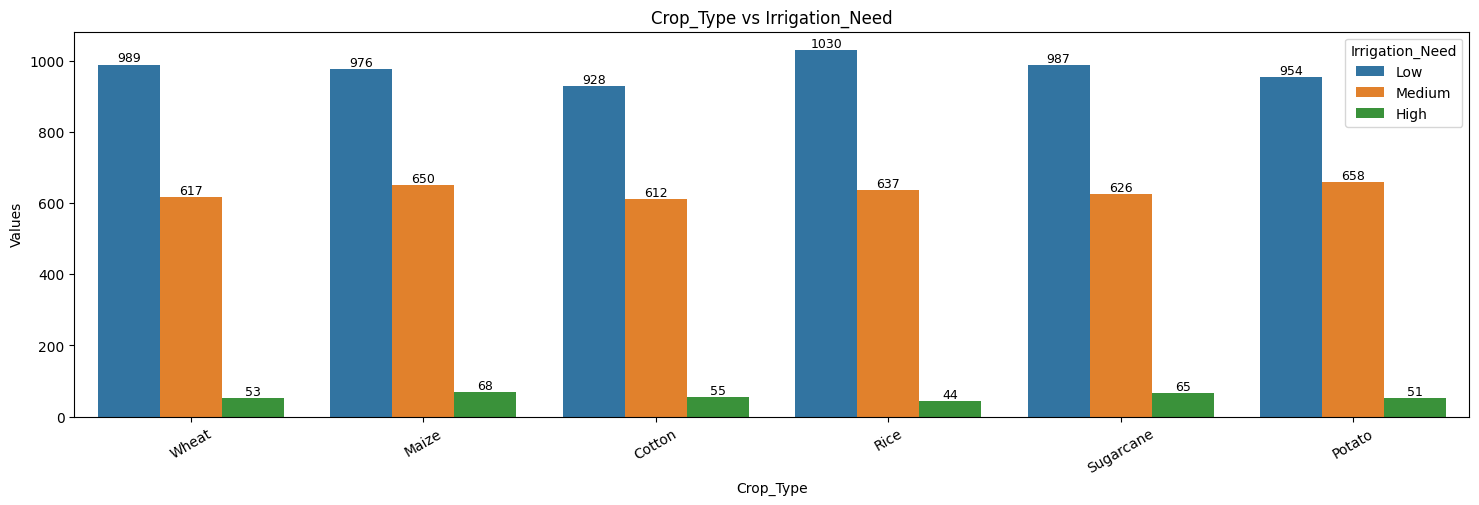

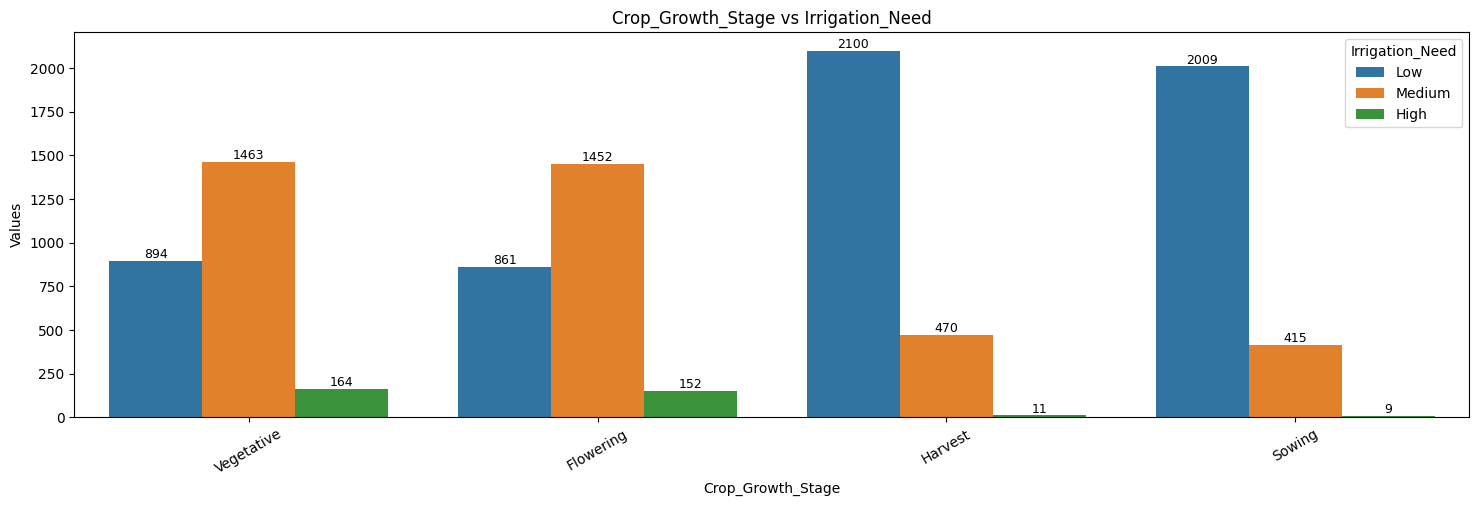

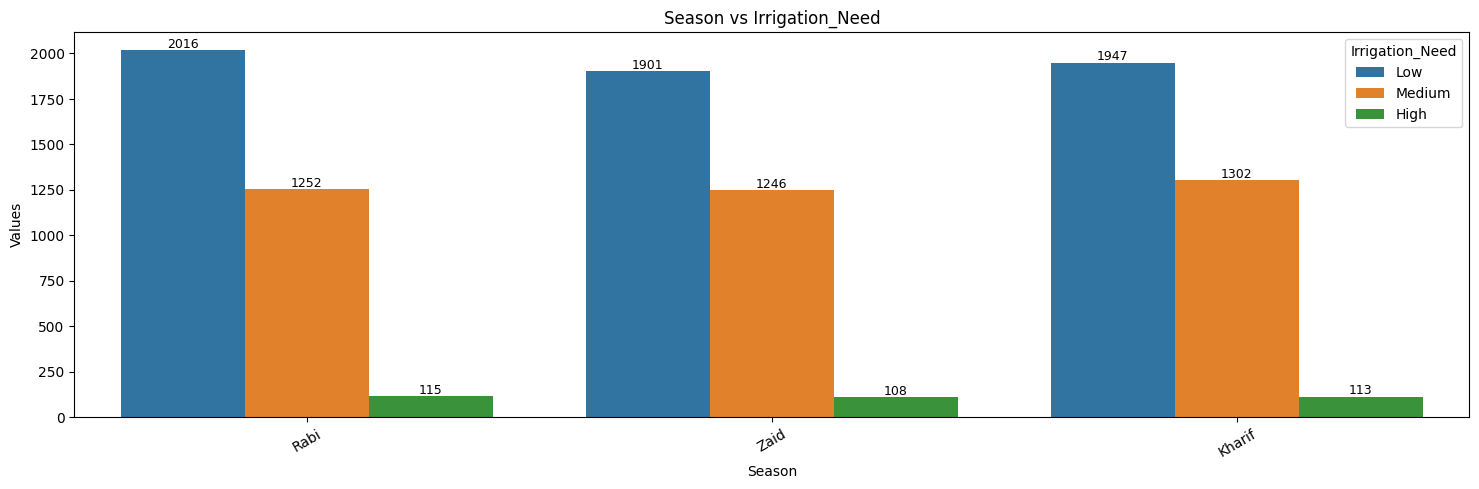

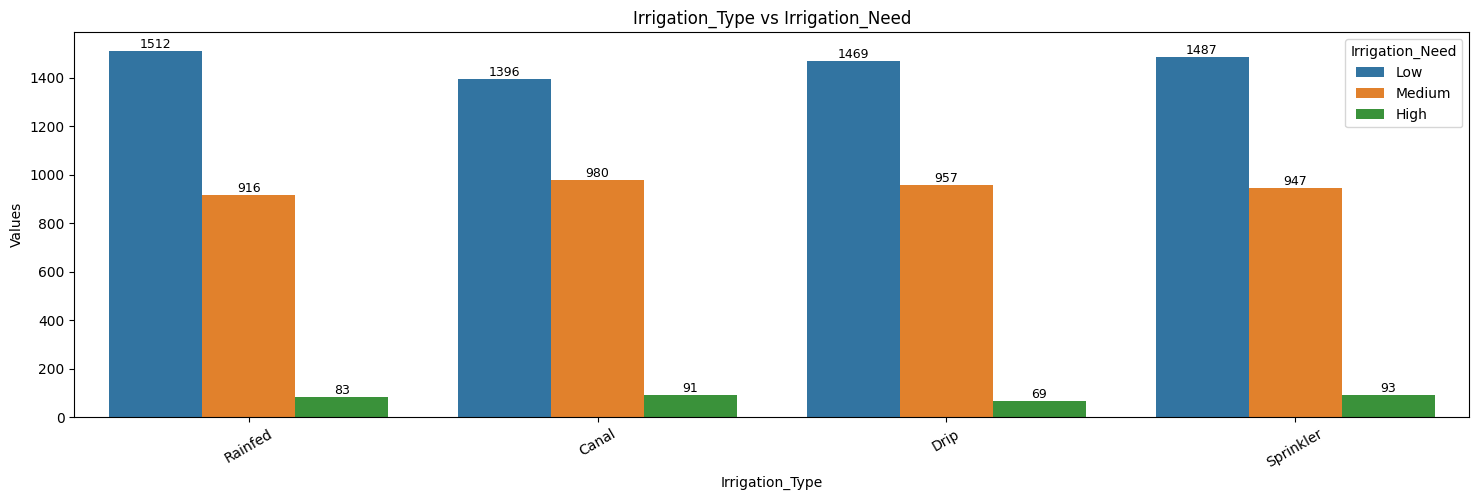

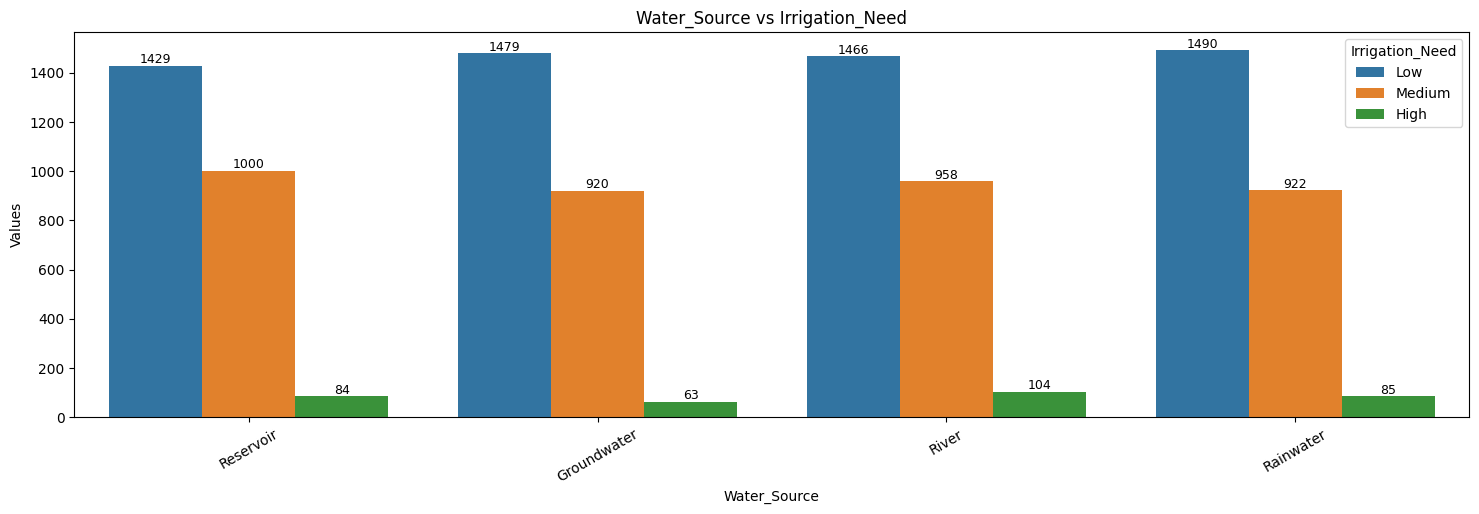

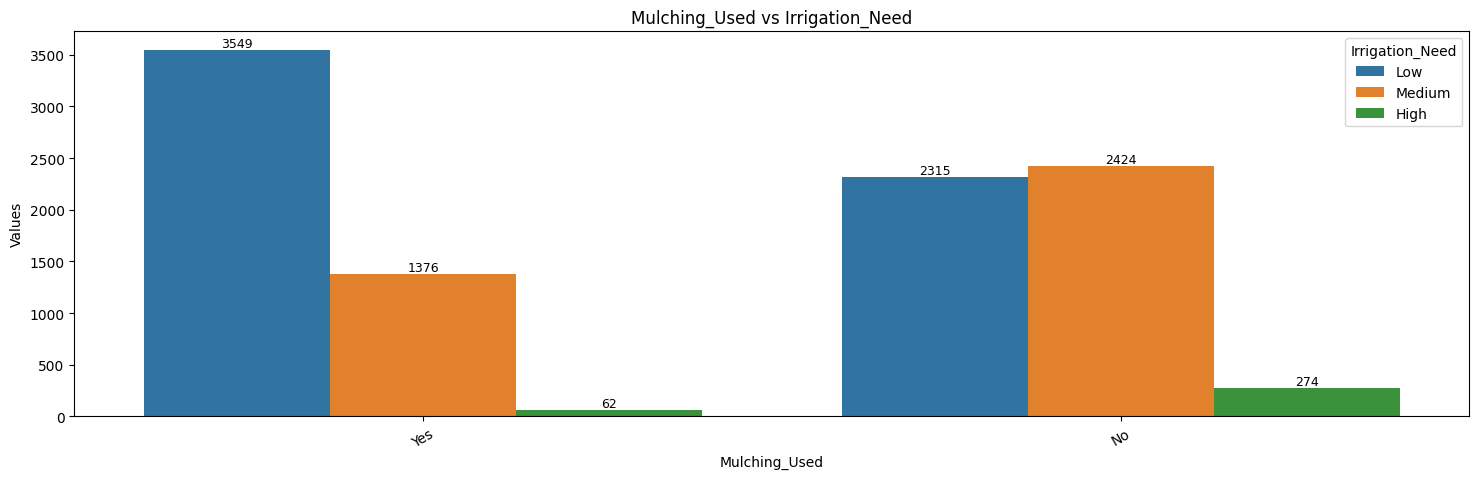

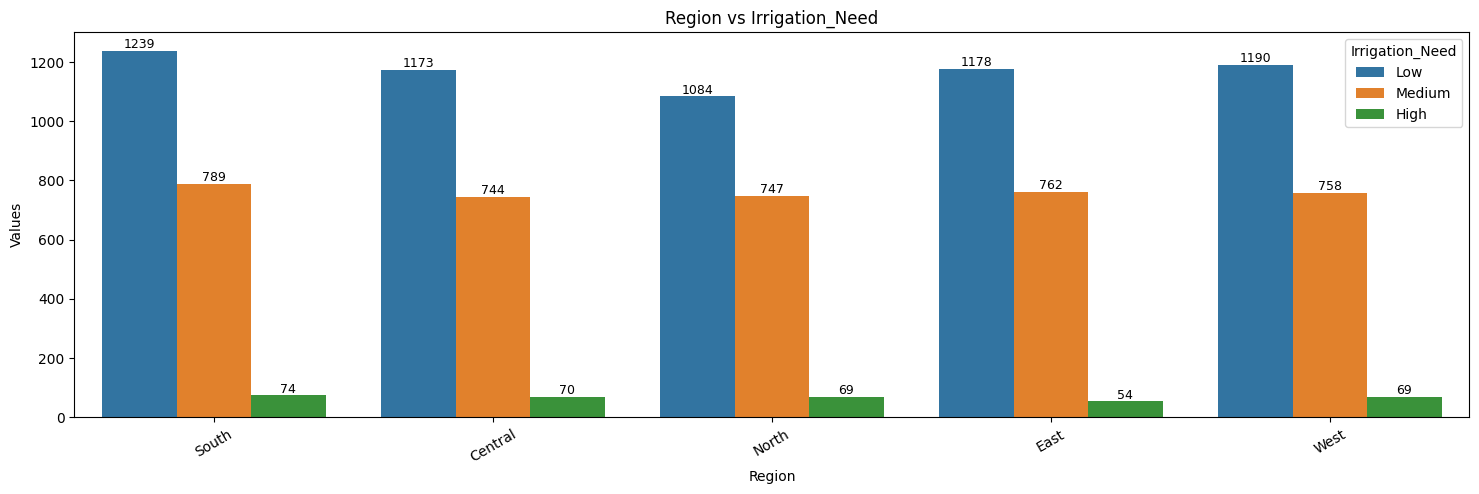

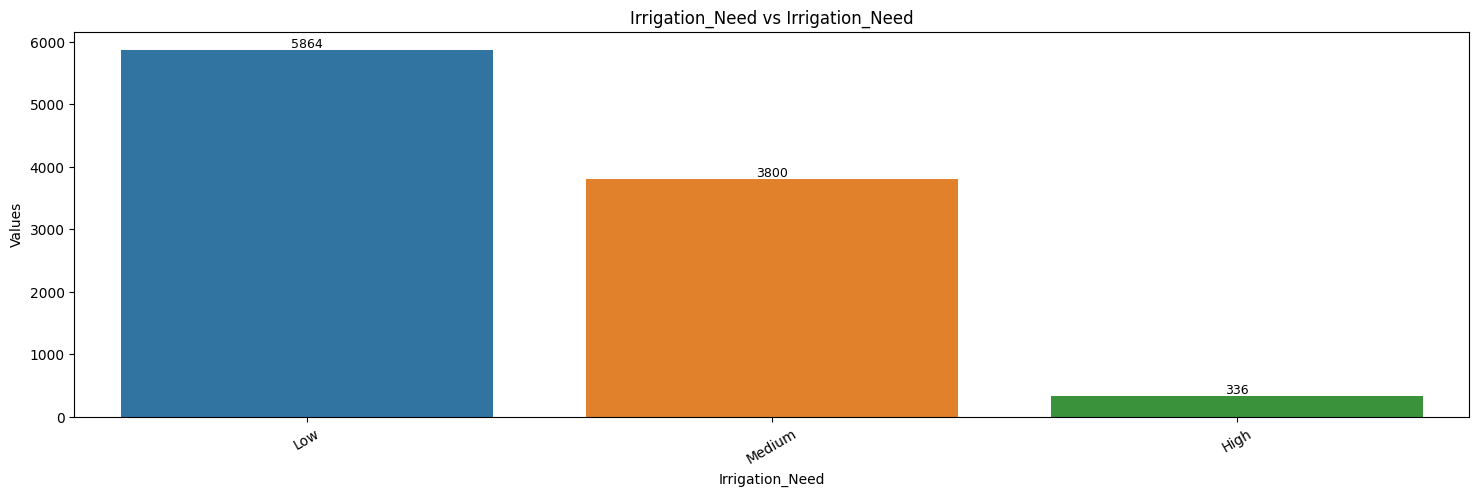

In [ ]:
# Etude de la relation entre les variables qualitatives et la target

for col in var_cat:
    plt.figure(figsize=(18, 5))
    
    ax = sns.countplot(x=col, data=df, hue="Irrigation_Need")
    
    # Ajouter les annotations
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(
                f'{int(height)}',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='baseline',
                fontsize=9, color='black',
                xytext=(0, 2),
                textcoords='offset points'
            )
    
    plt.ylabel("Values")
    plt.title(f"{col} vs Irrigation_Need")
    plt.xticks(rotation=30)
    
    plt.show()

In [16]:
from scipy.stats import chi2_contingency

# Liste pour stocker les résultats
chi2_results = []

for col in var_cat:
    # Tableau de contingence
    contingency = pd.crosstab(df[col], df['Irrigation_Need'])
    
    # Test Chi²
    chi2, p, dof, expected = chi2_contingency(contingency)
    
    # Décision statistique
    significance = "Significative" if p < 0.05 else "Non significative"
    
    # Dépendance
    dependence = "Dépendante" if p < 0.05 else "Indépendante"
    
    # Ajouter dans la liste
    chi2_results.append({
        "Variable": col,
        "Chi2": chi2,
        "p-value": p,
        "Signification": significance,
        "Dépendance": dependence
    })

# Convertir en DataFrame pour affichage
chi2_df = pd.DataFrame(chi2_results)
chi2_df.sort_values("p-value", inplace=True)

chi2_df

,Variable,Chi2,p-value,Signification,Dépendance
2,Crop_Growth_Stage,2291.619193,0.000000e+00,Significative,Dépendante
8,Irrigation_Need,20000.000000,0.000000e+00,Significative,Dépendante
6,Mulching_Used,682.405004,6.571072e-149,Significative,Dépendante
5,Water_Source,14.996889,2.028092e-02,Significative,Dépendante
4,Irrigation_Type,10.813354,9.431911e-02,Non significative,Indépendante
1,Crop_Type,11.004056,3.572021e-01,Non significative,Indépendante
0,Soil_Type,4.205004,6.489558e-01,Non significative,Indépendante
3,Season,2.300424,6.806918e-01,Non significative,Indépendante
7,Region,5.554900,6.969503e-01,Non significative,Indépendante


In [ ]:
#Comparaison du test Chi2 et Cramér's V

def cramers_v(confusion_matrix):
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    return np.sqrt(chi2 / (n * (min(r-1, k-1))))

# Liste pour stocker les résultats
results = []

for col in var_cat:
    # Tableau de contingence
    contingency = pd.crosstab(df[col], df['Irrigation_Need'])
    
    # Test Chi²
    chi2, p, dof, expected = chi2_contingency(contingency)
    
    # Cramér's V
    v = cramers_v(contingency)
    
    # Interprétation de la force
    if v < 0.1:
        strength = "Très faible"
    elif v < 0.3:
        strength = "Faible"
    elif v < 0.5:
        strength = "Modérée"
    else:
        strength = "Forte"
    
    significance = "Significative" if p < 0.05 else "Non significative"
    dependence = "Dépendante" if p < 0.05 else "Indépendante"
    
    # Stockage
    results.append({
        "Variable": col,
        "Chi2": chi2,
        "p-value": p,
        "Cramer's V": v,
        "Force de relation": strength,
        "Signification": significance,
        "Dépendance": dependence
    })

# DataFrame final
df_results = pd.DataFrame(results)
df_results.sort_values("Cramer's V", ascending=False, inplace=True)

df_results

,Variable,Chi2,p-value,Cramer's V,Force de relation,Signification,Dépendance
8,Irrigation_Need,20000.000000,0.000000e+00,1.000000,Forte,Significative,Dépendante
2,Crop_Growth_Stage,2291.619193,0.000000e+00,0.338498,Modérée,Significative,Dépendante
6,Mulching_Used,682.405004,6.571072e-149,0.261229,Faible,Significative,Dépendante
5,Water_Source,14.996889,2.028092e-02,0.027383,Très faible,Significative,Dépendante
1,Crop_Type,11.004056,3.572021e-01,0.023456,Très faible,Non significative,Indépendante
4,Irrigation_Type,10.813354,9.431911e-02,0.023252,Très faible,Non significative,Indépendante
7,Region,5.554900,6.969503e-01,0.016666,Très faible,Non significative,Indépendante
0,Soil_Type,4.205004,6.489558e-01,0.014500,Très faible,Non significative,Indépendante
3,Season,2.300424,6.806918e-01,0.010725,Très faible,Non significative,Indépendante


In [ ]:
# Décision sur les variables à garder

from scipy.stats import chi2_contingency

# Liste pour stocker les résultats
chi2_results = []

for col in var_cat:  # var_cat = liste des variables qualitatives
   
    contingency = pd.crosstab(df[col], df['Irrigation_Need'])
    
    chi2, p, dof, expected = chi2_contingency(contingency)
    
    # Décision "à garder" ou "à supprimer"
    # Critère : p-value < 0.05 → significatif → garder
    
    decision = "À garder" if p < 0.05 else "À supprimer"
    
    chi2_results.append({
        "Variable": col,
        "Chi2": round(chi2, 3),
        "p-value": round(p, 4),
        "Décision": decision
    })

# Convertir en DataFrame 
df_features_cat = pd.DataFrame(chi2_results).sort_values('p-value')
df_features_cat

,Variable,Chi2,p-value,Décision
2,Crop_Growth_Stage,2291.619,0.0000,À garder
6,Mulching_Used,682.405,0.0000,À garder
8,Irrigation_Need,20000.000,0.0000,À garder
5,Water_Source,14.997,0.0203,À garder
4,Irrigation_Type,10.813,0.0943,À supprimer
1,Crop_Type,11.004,0.3572,À supprimer
0,Soil_Type,4.205,0.6490,À supprimer
3,Season,2.300,0.6807,À supprimer
7,Region,5.555,0.6970,À supprimer


Il est surprenant de constater que certaines variables, telles que le type de sol, la saison, la région ou encore le type de semence, ne présentent aucune relation significative avec la variable cible.

En effet, intuitivement, on pourrait s’attendre à ce que le besoin en eau varie en fonction de la saison, du type de culture ou encore des caractéristiques du sol. Pourtant, dans le cas de notre jeu de données, cette relation ne ressort pas de manière évidente.

Etude univariée des variables numériques

In [19]:
#Sélection des variables numériques

var_num = df.select_dtypes(include=['float64', 'int']).columns.tolist()
var_num

['Soil_pH',
 'Soil_Moisture',
 'Organic_Carbon',
 'Electrical_Conductivity',
 'Temperature_C',
 'Humidity',
 'Rainfall_mm',
 'Sunlight_Hours',
 'Wind_Speed_kmh',
 'Field_Area_hectare',
 'Previous_Irrigation_mm']

In [20]:
df[var_num].describe()

,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,Previous_Irrigation_mm
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,6.487857,36.969207,0.944731,1.791963,26.991423,60.080339,1252.499420,7.518538,10.163545,7.598024,59.864122
std,0.979963,16.430845,0.372406,0.984202,8.664074,20.187973,715.582201,2.016077,5.670923,4.233919,34.483722
min,4.800000,8.000000,0.300000,0.100000,12.000000,25.000000,0.380000,4.000000,0.500000,0.300000,0.020000
25%,5.640000,22.860000,0.620000,0.940000,19.460000,42.855000,634.155000,5.760000,5.160000,3.950000,30.160000
50%,6.470000,37.240000,0.950000,1.780000,27.090000,60.040000,1250.335000,7.560000,10.190000,7.540000,59.630000
75%,7.350000,50.940000,1.260000,2.650000,34.500000,77.705000,1880.265000,9.260000,15.100000,11.202500,90.030000
max,8.200000,65.000000,1.600000,3.500000,42.000000,95.000000,2499.690000,11.000000,20.000000,15.000000,119.990000


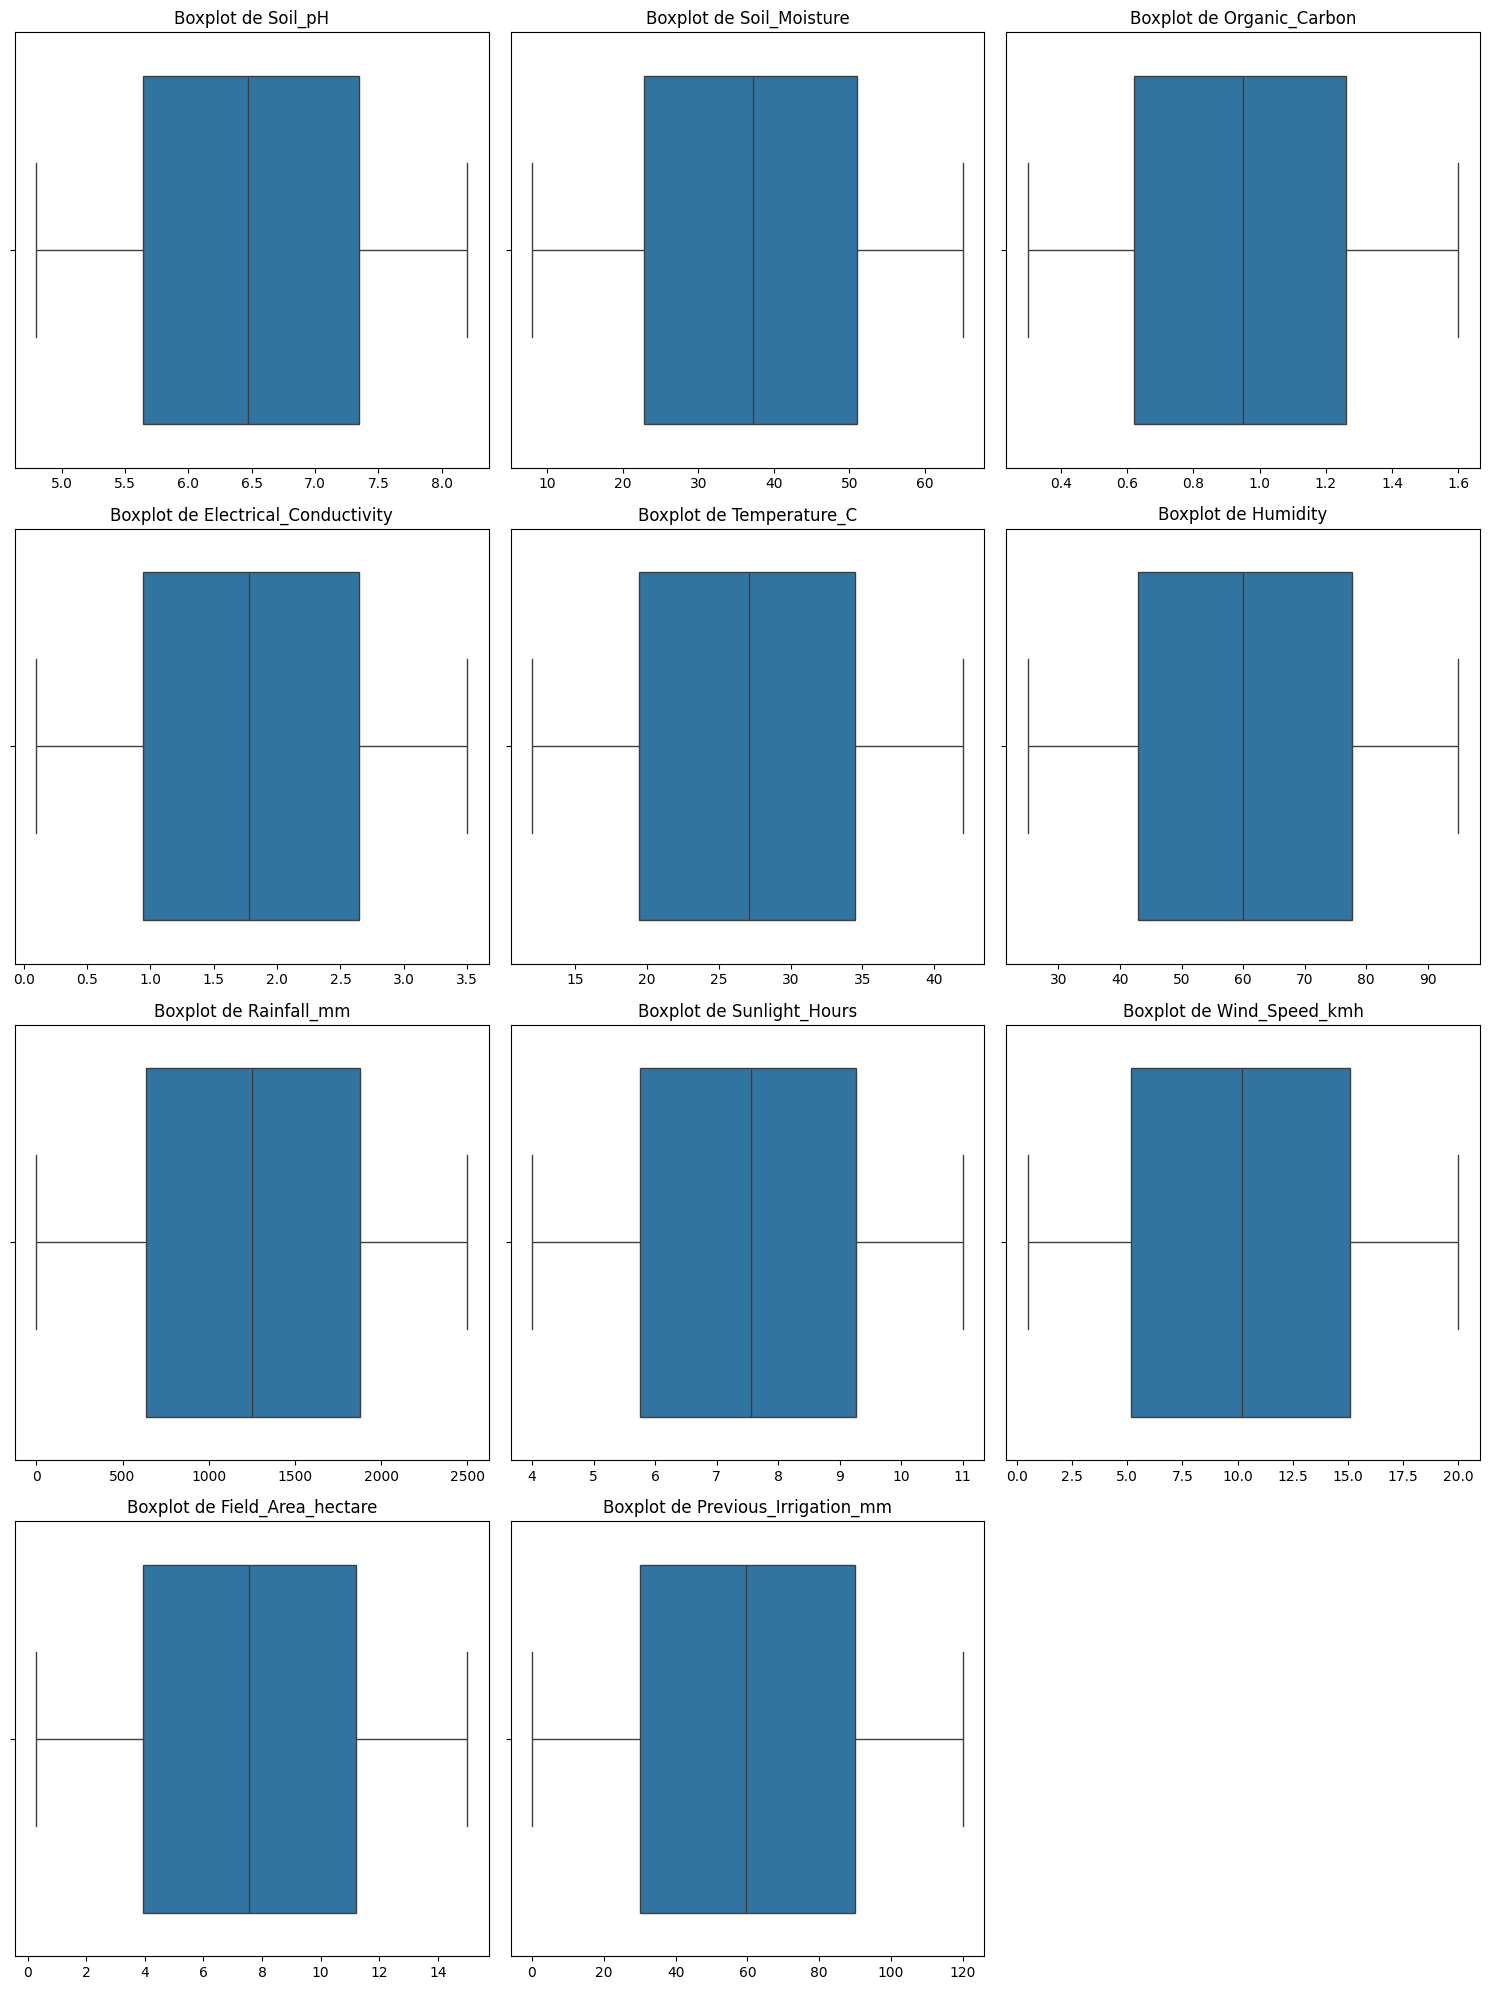

In [51]:
#Vérifios s'il y a d'outliers dans notre dataset....

n = len(var_num)
cols = 3
rows = math.ceil(n / cols)

plt.figure(figsize=(15, 5 * rows))

for i, col in enumerate(var_num, 1):
    plt.subplot(rows, cols, i)
    sns.boxplot(data=df, x=col)
    plt.title(f"Boxplot de {col}")
    plt.xlabel("")

plt.tight_layout()
plt.show()

Ce jeu de données ne met en évidence aucune valeur aberrante.
Les observations sont sans présence de valeurs extrêmes susceptibles de biaiser les résultats des analyses statistiques ou des modèles.

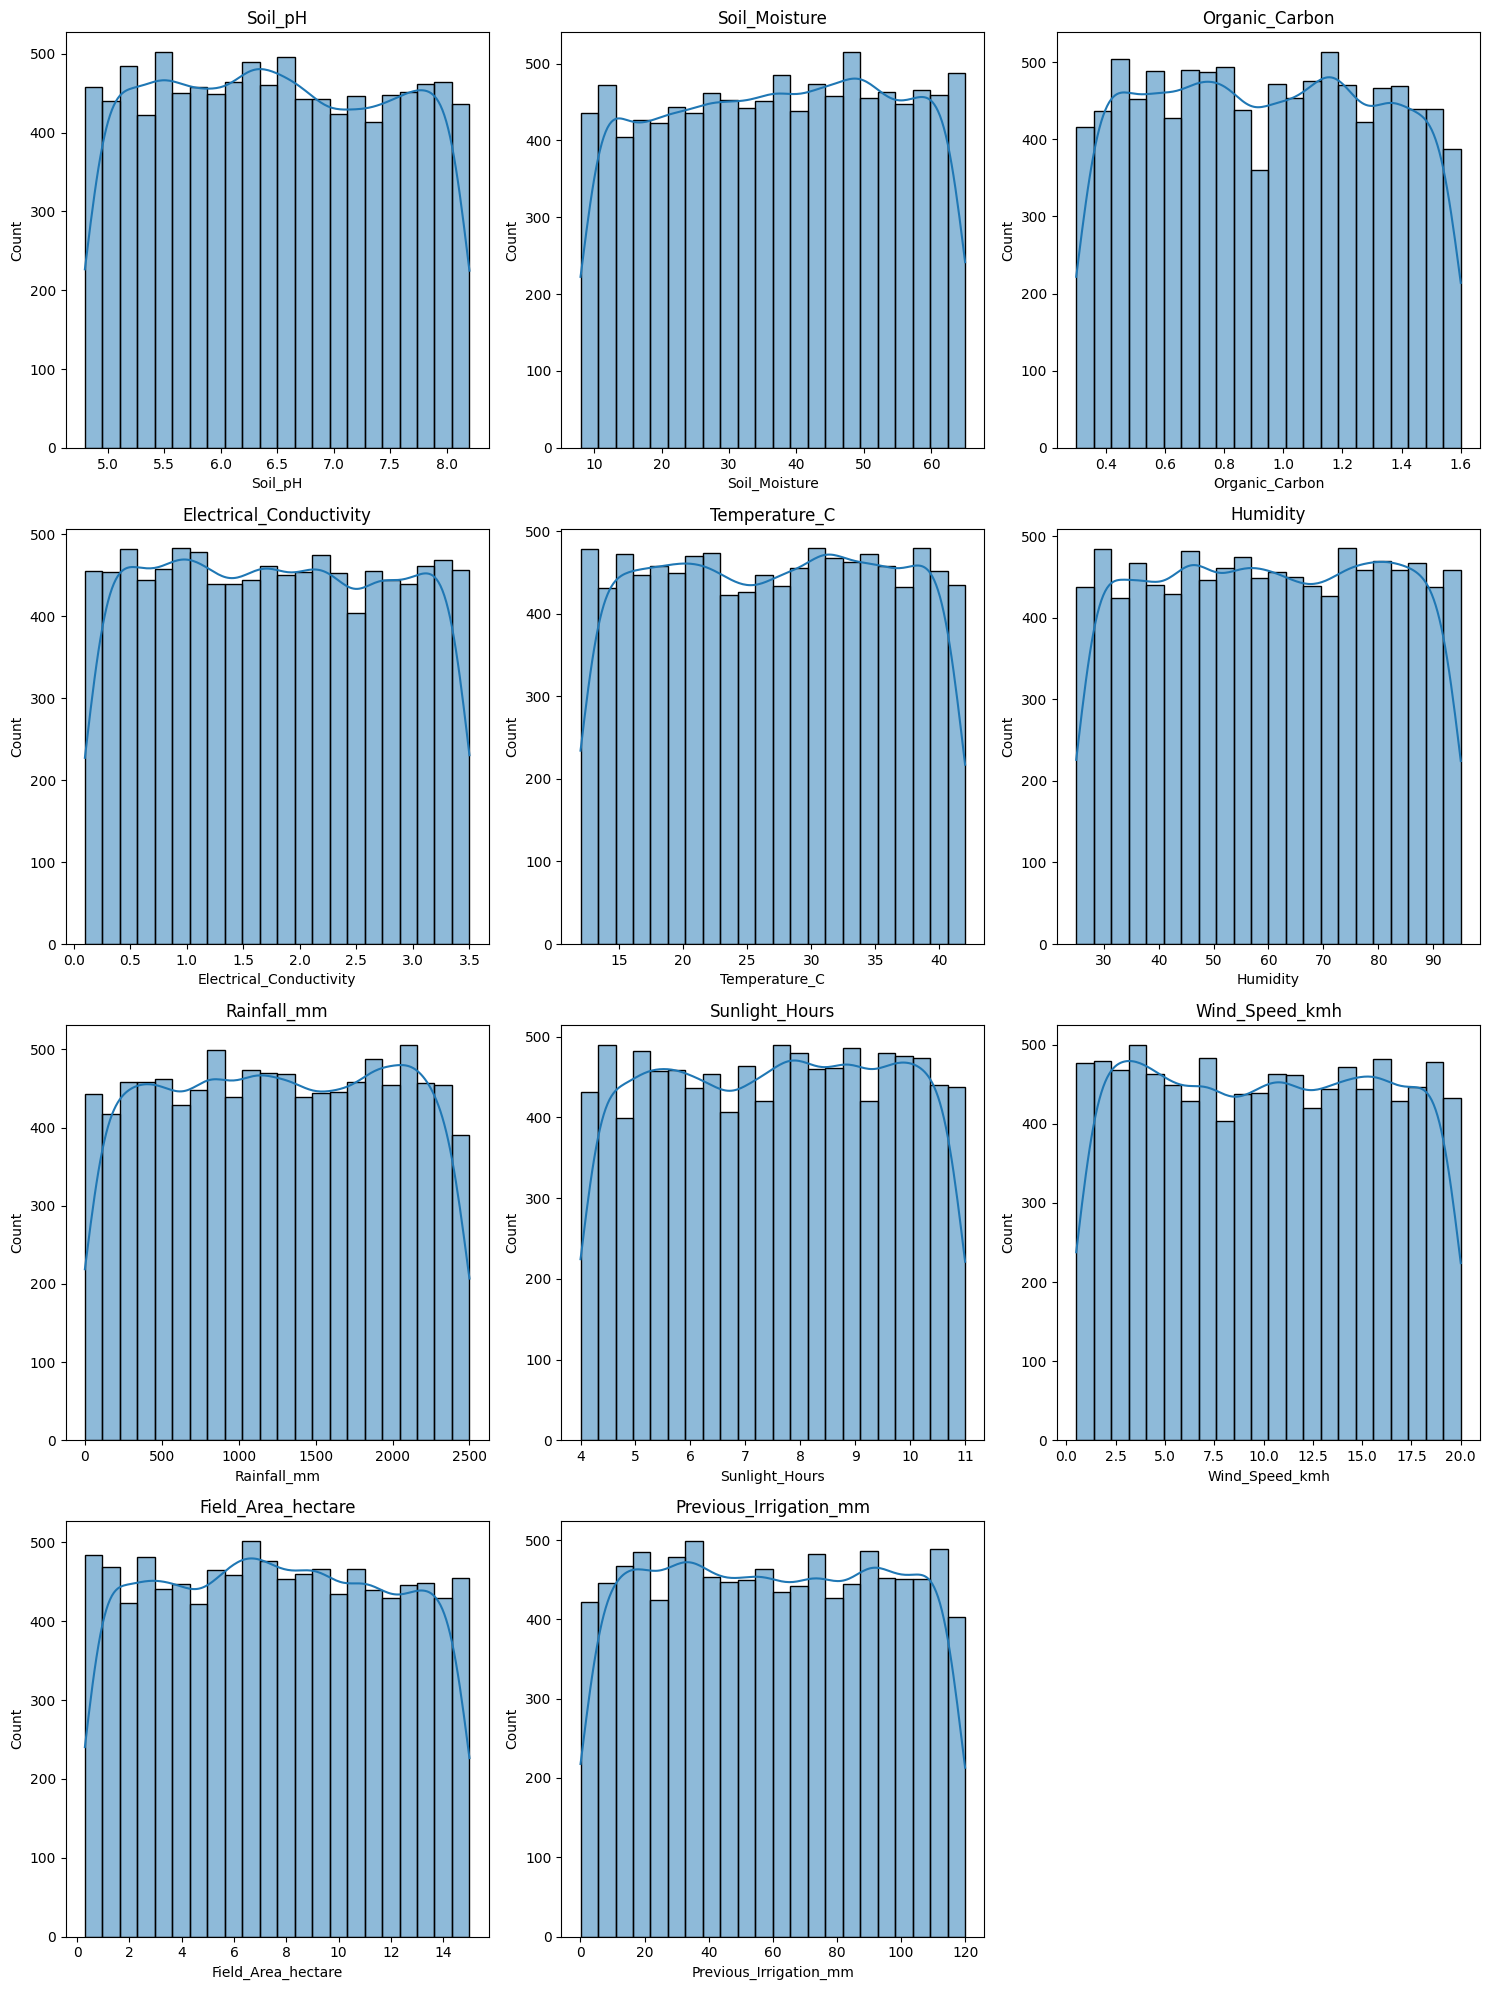

In [ ]:
#Etude de la distribution des variables

n = len(var_num)
cols = 3
rows = math.ceil(n / cols)

plt.figure(figsize=(15, 5 * rows))

for i, col in enumerate(var_num, 1):
    plt.subplot(rows, cols, i)
    sns.histplot(df[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

In [ ]:
#Etude de la distribution asymétrique des variables numériques.
df[var_num].skew().sort_values(ascending=False)

Soil_pH                    0.027393
Electrical_Conductivity    0.019496
Organic_Carbon             0.015585
Field_Area_hectare         0.012171
Wind_Speed_kmh             0.011954
Previous_Irrigation_mm     0.006771
Humidity                  -0.006708
Temperature_C             -0.011421
Rainfall_mm               -0.012740
Sunlight_Hours            -0.020983
Soil_Moisture             -0.039792
dtype: float64

Tout semble correct... Les variables sont symétriquement distribuées. C'est bon signe.

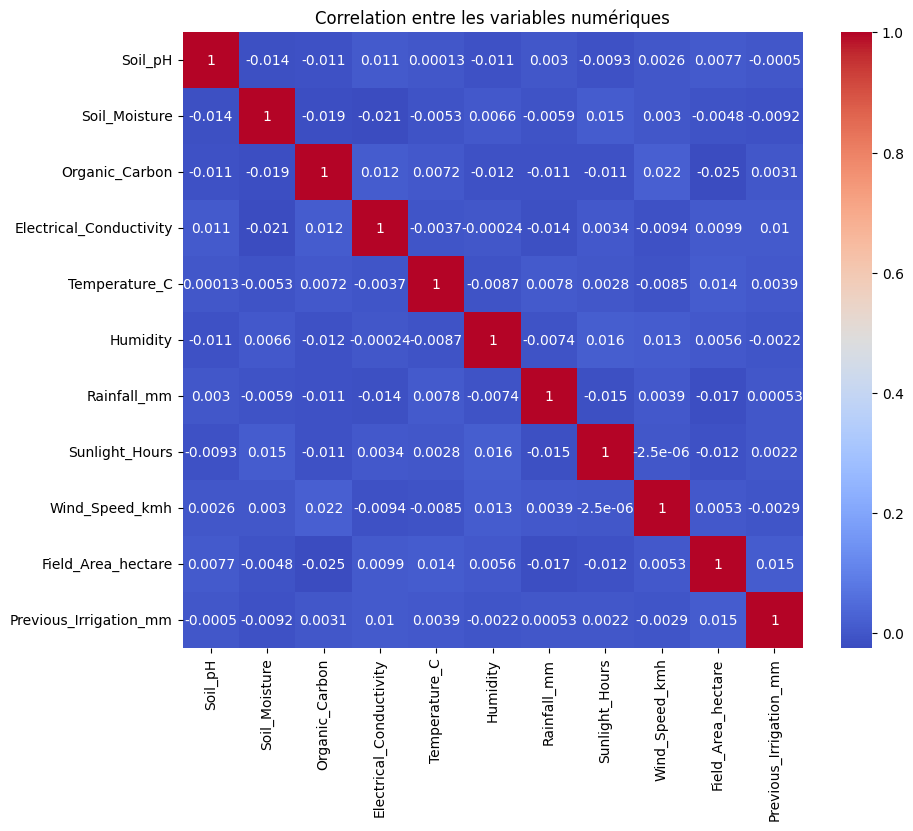

In [ ]:
#Etude de la multicolinéarité entre les variables numériques. 

plt.figure(figsize=(10, 8))
sns.heatmap(df[var_num].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation entre les variables numériques")
plt.show()

Il y a une abscence de multicolinéarité entre les variables.

In [ ]:
df.columns

Index(['Soil_Type', 'Soil_pH', 'Soil_Moisture', 'Organic_Carbon',
       'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm',
       'Sunlight_Hours', 'Wind_Speed_kmh', 'Crop_Type', 'Crop_Growth_Stage',
       'Season', 'Irrigation_Type', 'Water_Source', 'Field_Area_hectare',
       'Mulching_Used', 'Previous_Irrigation_mm', 'Region', 'Irrigation_Need'],
      dtype='object')

In [ ]:
from scipy.stats import f_oneway

for col in var_num:
    groups = [df[df['Irrigation_Need']==c][col] for c in df['Irrigation_Need'].unique()]
    f_stat, p_val = f_oneway(*groups)
    print(f'{col} : F={f_stat:.2f}, p-value={p_val:.3f}')
    print("=============================================")
    print("")

Soil_pH : F=0.62, p-value=0.539

Soil_Moisture : F=771.85, p-value=0.000

Organic_Carbon : F=0.34, p-value=0.713

Electrical_Conductivity : F=0.64, p-value=0.526

Temperature_C : F=245.45, p-value=0.000

Humidity : F=0.60, p-value=0.547

Rainfall_mm : F=199.00, p-value=0.000

Sunlight_Hours : F=0.17, p-value=0.847

Wind_Speed_kmh : F=265.19, p-value=0.000

Field_Area_hectare : F=1.17, p-value=0.309

Previous_Irrigation_mm : F=0.85, p-value=0.427



In [ ]:
# Etude de l'intensité de la relation entre les variables quantitatives et la target

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_enc = le.fit_transform(df['Irrigation_Need'])

for col in var_num:
    eta_squared = np.var([df[df['Irrigation_Need']==c][col].mean() for c in df['Irrigation_Need'].unique()]) / df[col].var()
    print(f'{col} : eta² = {eta_squared:.2f}')
    
    print("======================================")
    print("")

Soil_pH : eta² = 0.00

Soil_Moisture : eta² = 0.30

Organic_Carbon : eta² = 0.00

Electrical_Conductivity : eta² = 0.00

Temperature_C : eta² = 0.12

Humidity : eta² = 0.00

Rainfall_mm : eta² = 0.15

Sunlight_Hours : eta² = 0.00

Wind_Speed_kmh : eta² = 0.11

Field_Area_hectare : eta² = 0.00

Previous_Irrigation_mm : eta² = 0.00



In [ ]:
#Etude de la relation entre les variables quantitatives et la target

from scipy.stats import kruskal

results = []

for col in var_num:
    groups = [df[df['Irrigation_Need'] == c][col] for c in df['Irrigation_Need'].unique()]
    
    # ANOVA 
    f_stat, p_val_anova = f_oneway(*groups)
    
    # Test de Kruskal-Wallis
    stat_kruskal, p_val_kruskal = kruskal(*groups)
    
    # Evaluation de la force de relation
    eta_squared = np.var([df[df['Irrigation_Need']==c][col].mean() for c in df['Irrigation_Need'].unique()]) / df[col].var()
    
    # Décision "à garder" ou "à supprimer"
    # Critère : p-value ANOVA < 0.05 ou Eta² > 0.1 → garder
    if (p_val_anova < 0.05) or (eta_squared > 0.1):
        decision = "À garder"
    else:
        decision = "À supprimer"
    
    # Ajouter aux résultats
    results.append({
        'Variable': col,
        'ANOVA_p_value': round(p_val_anova, 4),
        'Kruskal_p_value': round(p_val_kruskal, 4),
        'Eta²': round(eta_squared, 3),
        'Décision_Stat': decision
    })

# Convertir en DataFrame et trier par Eta² décroissante
df_features = pd.DataFrame(results).sort_values('Eta²', ascending=False)
df_features

,Variable,ANOVA_p_value,Kruskal_p_value,Eta²,Décision
1,Soil_Moisture,0.0000,0.0000,0.299,À garder
6,Rainfall_mm,0.0000,0.0000,0.155,À garder
4,Temperature_C,0.0000,0.0000,0.120,À garder
8,Wind_Speed_kmh,0.0000,0.0000,0.106,À garder
0,Soil_pH,0.5391,0.5566,0.001,À supprimer
3,Electrical_Conductivity,0.5260,0.5259,0.001,À supprimer
2,Organic_Carbon,0.7134,0.7102,0.000,À supprimer
5,Humidity,0.5469,0.5434,0.000,À supprimer
7,Sunlight_Hours,0.8474,0.8435,0.000,À supprimer
9,Field_Area_hectare,0.3091,0.2997,0.000,À supprimer


In [23]:
df.columns

Index(['Soil_Type', 'Soil_pH', 'Soil_Moisture', 'Organic_Carbon',
       'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm',
       'Sunlight_Hours', 'Wind_Speed_kmh', 'Crop_Type', 'Crop_Growth_Stage',
       'Season', 'Irrigation_Type', 'Water_Source', 'Field_Area_hectare',
       'Mulching_Used', 'Previous_Irrigation_mm', 'Region', 'Irrigation_Need'],
      dtype='object')

Au regards des analyses exploratoires effectuée et des recommandations des experts du métiers les variables ci-dessous
seront retenus pour le model : 

Soil_Type, Soil_Moisture, Rainfall_mm, Crop_Type, Crop_Growth_Stage, Season, Field_Area_hectare, Mulching_Used, Previous_Irrigation_mm, Region


In [ ]:
# Selection définitive des varibales à utiliser et enregistrement dans une nouvelle dataframe
# De 20 varibales au départ, on e retrouve à 10 soit 6 variables catégorielles et 4 variables numériques

selected_features = [
    'Soil_Type',
    'Soil_Moisture',
    'Rainfall_mm',
    'Crop_Type',
    'Crop_Growth_Stage',
    'Season',
    'Field_Area_hectare',
    'Mulching_Used',
    'Previous_Irrigation_mm',
    'Region'
]

target = 'Irrigation_Need'

df_model = df[selected_features + [target]].copy()

In [25]:
df_model.shape

(10000, 11)

In [26]:
df_model.dtypes

Soil_Type                  object
Soil_Moisture             float64
Rainfall_mm               float64
Crop_Type                  object
Crop_Growth_Stage          object
Season                     object
Field_Area_hectare        float64
Mulching_Used              object
Previous_Irrigation_mm    float64
Region                     object
Irrigation_Need            object
dtype: object

In [27]:
df_model.head()

,Soil_Type,Soil_Moisture,Rainfall_mm,Crop_Type,Crop_Growth_Stage,Season,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,Clay,36.48,1167.70,Wheat,Vegetative,Rabi,4.73,Yes,1.98,South,Low
1,Silt,50.56,831.28,Maize,Flowering,Zaid,12.22,Yes,33.56,Central,Medium
2,Sandy,40.07,1844.45,Cotton,Harvest,Rabi,5.52,Yes,34.62,South,Low
3,Clay,12.75,306.26,Wheat,Sowing,Kharif,1.43,Yes,84.03,North,Medium
4,Clay,18.58,1875.63,Cotton,Sowing,Zaid,2.52,No,60.86,South,Medium


In [28]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Soil_Type               10000 non-null  object 
 1   Soil_Moisture           10000 non-null  float64
 2   Rainfall_mm             10000 non-null  float64
 3   Crop_Type               10000 non-null  object 
 4   Crop_Growth_Stage       10000 non-null  object 
 5   Season                  10000 non-null  object 
 6   Field_Area_hectare      10000 non-null  float64
 7   Mulching_Used           10000 non-null  object 
 8   Previous_Irrigation_mm  10000 non-null  float64
 9   Region                  10000 non-null  object 
 10  Irrigation_Need         10000 non-null  object 
dtypes: float64(4), object(7)
memory usage: 859.5+ KB


In [ ]:
# Séparation de la dataset en train et en test (20% pour le test)

X = df_model.drop(columns='Irrigation_Need')
y = df_model['Irrigation_Need']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
#Encodage des variables catégorielles

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# Variables
num_vars = ['Soil_Moisture', 'Rainfall_mm', 'Field_Area_hectare', 'Previous_Irrigation_mm']
cat_nominal = ['Soil_Type', 'Crop_Type', 'Season', 'Region']

# Encodae manuel des variables catégorielle ordinal
X_train['Crop_Growth_Stage'] = X_train['Crop_Growth_Stage'].map({
    'Sowing': 0, 'Vegetative': 1, 'Flowering': 2, 'Harvest': 3
})
X_test['Crop_Growth_Stage'] = X_test['Crop_Growth_Stage'].map({
    'Sowing': 0, 'Vegetative': 1, 'Flowering': 2, 'Harvest': 3
})

# Encodage des variables Binaires
X_train['Mulching_Used'] = X_train['Mulching_Used'].map({'No': 0, 'Yes': 1})
X_test['Mulching_Used'] = X_test['Mulching_Used'].map({'No': 0, 'Yes': 1})

# Préprocessing
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_vars),
    ('cat', OneHotEncoder(drop='first'), cat_nominal)
], remainder='passthrough')

In [32]:
#Conception du modele de regression logistique multiple

from sklearn.linear_model import LogisticRegression

pipe_log = ImbPipeline([
    ('prep', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

pipe_log.fit(X_train, y_train)
y_pred_log = pipe_log.predict(X_test)

In [ ]:
# Comception du modèle de Forêt aléatoire

from sklearn.ensemble import RandomForestClassifier

pipe_rf = ImbPipeline([
    ('prep', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42))
])

pipe_rf.fit(X_train, y_train)
y_pred_rf = pipe_rf.predict(X_test)

In [ ]:
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, confusion_matrix

# Encoder la target (Low=0, Medium=1, High=2 ---
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train) 
y_test_enc = le.transform(y_test)

# Construire le pipeline XGBoost (Encodge, Scaling et gestion du deséquilibre de la target ---------
pipe_xgb = ImbPipeline([
    ('prep', preprocessor),                
    ('smote', SMOTE(random_state=42)),    
    ('model', xgb.XGBClassifier(
        objective='multi:softprob',       
        num_class=3,
        eval_metric='mlogloss',           
        use_label_encoder=False,      
        random_state=42
    ))
])

# ---Entraînement ---
pipe_xgb.fit(X_train, y_train_enc)

# ---Prédictions ---
y_pred_xgb_enc = pipe_xgb.predict(X_test)

# ---Retour aux labels originaux ---
y_pred_xgb = le.inverse_transform(y_pred_xgb_enc)


In [ ]:
# Évaluation des trois modèls 

def evaluate_model(y_test, y_pred, name):
    print(f"\n=== {name} ===")
    print(classification_report(y_test, y_pred))
    print("Matrice de confusion :")
    print(confusion_matrix(y_test, y_pred))

evaluate_model(y_test, y_pred_log, "Logistic Regression")
evaluate_model(y_test, y_pred_rf, "Random Forest")
evaluate_model(y_test, y_pred_xgb, "XGBoost")



=== Logistic Regression ===
              precision    recall  f1-score   support

        High       0.15      0.70      0.24        67
         Low       0.77      0.67      0.72      1173
      Medium       0.48      0.41      0.45       760

    accuracy                           0.57      2000
   macro avg       0.47      0.60      0.47      2000
weighted avg       0.64      0.57      0.60      2000

Matrice de confusion :
[[ 47   2  18]
 [ 66 788 319]
 [207 239 314]]

=== Random Forest ===
              precision    recall  f1-score   support

        High       0.67      0.54      0.60        67
         Low       0.91      0.87      0.89      1173
      Medium       0.78      0.85      0.81       760

    accuracy                           0.85      2000
   macro avg       0.79      0.75      0.77      2000
weighted avg       0.85      0.85      0.85      2000

Matrice de confusion :
[[  36    0   31]
 [   0 1026  147]
 [  18   99  643]]

=== XGBoost ===
              precisio

In [36]:
df.head(10)

,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,Clay,6.14,36.48,0.42,2.17,21.90,31.19,1167.70,4.01,1.97,Wheat,Vegetative,Rabi,Rainfed,Reservoir,4.73,Yes,1.98,South,Low
1,Silt,6.41,50.56,0.38,0.23,36.50,26.01,831.28,10.72,16.82,Maize,Flowering,Zaid,Canal,Groundwater,12.22,Yes,33.56,Central,Medium
2,Sandy,7.71,40.07,1.09,2.18,41.83,76.41,1844.45,7.75,19.03,Cotton,Harvest,Rabi,Drip,Reservoir,5.52,Yes,34.62,South,Low
3,Clay,5.96,12.75,1.56,0.40,37.22,43.32,306.26,8.90,11.44,Wheat,Sowing,Kharif,Canal,Reservoir,1.43,Yes,84.03,North,Medium
4,Clay,7.76,18.58,0.95,2.52,22.38,86.44,1875.63,10.39,11.26,Cotton,Sowing,Zaid,Canal,River,2.52,No,60.86,South,Medium
5,Silt,5.10,20.50,0.37,1.43,33.34,62.51,402.92,7.03,13.55,Rice,Sowing,Zaid,Sprinkler,Groundwater,7.56,Yes,7.33,East,Medium
6,Sandy,7.44,22.70,0.59,2.95,28.02,58.50,764.95,7.08,7.38,Rice,Flowering,Kharif,Sprinkler,Reservoir,2.18,No,51.47,West,Medium
7,Sandy,7.68,40.23,0.62,3.30,35.60,79.10,833.33,5.17,3.73,Wheat,Vegetative,Zaid,Rainfed,Reservoir,12.54,Yes,118.96,West,Low
8,Clay,5.42,36.73,0.74,1.52,16.59,76.88,2476.03,10.34,1.80,Maize,Flowering,Kharif,Sprinkler,Rainwater,13.75,Yes,107.25,Central,Low
9,Loamy,6.26,19.58,0.36,1.67,31.14,74.30,1474.55,8.53,17.68,Rice,Vegetative,Rabi,Rainfed,Reservoir,1.27,Yes,97.92,Central,Medium


In [37]:
X_train.head()

,Soil_Type,Soil_Moisture,Rainfall_mm,Crop_Type,Crop_Growth_Stage,Season,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region
6998,Sandy,52.40,2151.20,Wheat,2,Zaid,2.53,1,15.00,South
6594,Sandy,45.35,1897.01,Maize,0,Zaid,4.63,1,118.65,Central
7799,Sandy,24.25,194.28,Potato,0,Kharif,14.16,1,10.73,East
8727,Clay,12.22,177.38,Sugarcane,1,Kharif,6.88,0,66.60,North
9321,Clay,32.52,1559.48,Potato,1,Kharif,4.45,0,77.24,South


In [ ]:
# Faire un test
X_new = pd.DataFrame([{
    'Soil_Type': "Sandy",
    'Soil_Moisture': 52.4,
    'Rainfall_mm': 2152.2,
    'Crop_Type': "Wheat",
    'Crop_Growth_Stage': 2,
    'Season': "Zaid",
    'Field_Area_hectare': 2.53,
    'Mulching_Used': 1,
    'Previous_Irrigation_mm': 15.5,
    'Region': "South"
}])

# Prédiction
y_new_pred = pipe_rf.predict(X_new)

In [39]:
print(y_new_prob)

[[0.   0.28 0.72]]


In [40]:
print(y_new_pred)

['Medium']


In [41]:
X_test.head()

,Soil_Type,Soil_Moisture,Rainfall_mm,Crop_Type,Crop_Growth_Stage,Season,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region
4049,Silt,26.10,1416.90,Sugarcane,2,Zaid,7.25,0,51.55,North
5162,Sandy,46.46,64.11,Rice,2,Kharif,2.11,0,32.89,West
5202,Clay,35.79,1626.18,Wheat,2,Zaid,7.51,1,79.52,South
7396,Clay,58.75,650.84,Cotton,2,Rabi,14.18,0,20.98,Central
2521,Loamy,41.98,513.85,Maize,1,Rabi,7.15,1,19.48,East


In [ ]:
# Prédiction pour tout X_test
y_pred_test = pipe_rf.predict(X_test)

# Afficher les prédictions
y_pred_test

array(['Medium', 'Medium', 'Low', ..., 'Low', 'Low', 'Medium'],
      dtype=object)

In [43]:
df_pred = X_test.copy()
df_pred['Predicted_Irrigation_Need'] = y_pred_test

df_pred.head(100)

,Soil_Type,Soil_Moisture,Rainfall_mm,Crop_Type,Crop_Growth_Stage,Season,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Predicted_Irrigation_Need
4049,Silt,26.10,1416.90,Sugarcane,2,Zaid,7.25,0,51.55,North,Medium
5162,Sandy,46.46,64.11,Rice,2,Kharif,2.11,0,32.89,West,Medium
5202,Clay,35.79,1626.18,Wheat,2,Zaid,7.51,1,79.52,South,Low
7396,Clay,58.75,650.84,Cotton,2,Rabi,14.18,0,20.98,Central,Medium
2521,Loamy,41.98,513.85,Maize,1,Rabi,7.15,1,19.48,East,Low
...,...,...,...,...,...,...,...,...,...,...,...
143,Silt,31.84,1405.61,Sugarcane,3,Zaid,2.62,0,80.44,North,Low
9877,Silt,14.00,180.06,Wheat,2,Kharif,2.97,0,67.87,South,High
3533,Loamy,26.87,1535.43,Potato,2,Rabi,14.21,0,71.81,East,Medium
1053,Clay,51.18,1880.62,Rice,1,Rabi,8.20,0,68.71,West,Medium


In [44]:
df_pred.describe()

,Soil_Moisture,Rainfall_mm,Crop_Growth_Stage,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,36.268025,1256.175600,1.532500,7.542925,0.500000,60.828680
std,16.315160,727.363026,1.122753,4.220026,0.500125,35.100207
min,8.020000,1.640000,0.000000,0.300000,0.000000,0.020000
25%,22.625000,620.857500,1.000000,3.940000,0.000000,29.065000
50%,36.490000,1246.110000,2.000000,7.410000,0.500000,61.875000
75%,49.837500,1910.967500,3.000000,11.152500,1.000000,91.090000
max,64.990000,2499.580000,3.000000,15.000000,1.000000,119.830000


In [45]:
import joblib

# Sauvegarde du pipeline complet

joblib.dump(pipe_rf, "rf_irrigation_model.joblib", compress=3)

print(f"Modèle sauvegardé dans")

Modèle sauvegardé dans


In [ ]:
X_test.columns

Index(['Soil_Type', 'Soil_Moisture', 'Rainfall_mm', 'Crop_Type',
       'Crop_Growth_Stage', 'Season', 'Field_Area_hectare', 'Mulching_Used',
       'Previous_Irrigation_mm', 'Region'],
      dtype='object')